For illustration purposes the scrip was executed with posterize transform only and fraction of copied samples equal to [0,0.1,0.2,0.5] \
To reproduce figures from paper, un-comment the beta_values and other transforms in the .py and here

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [3]:
with open('./output/comparison_dinov2_METRICS_DIC.pickle', 'rb') as handle:
    metrics = pickle.load(handle)

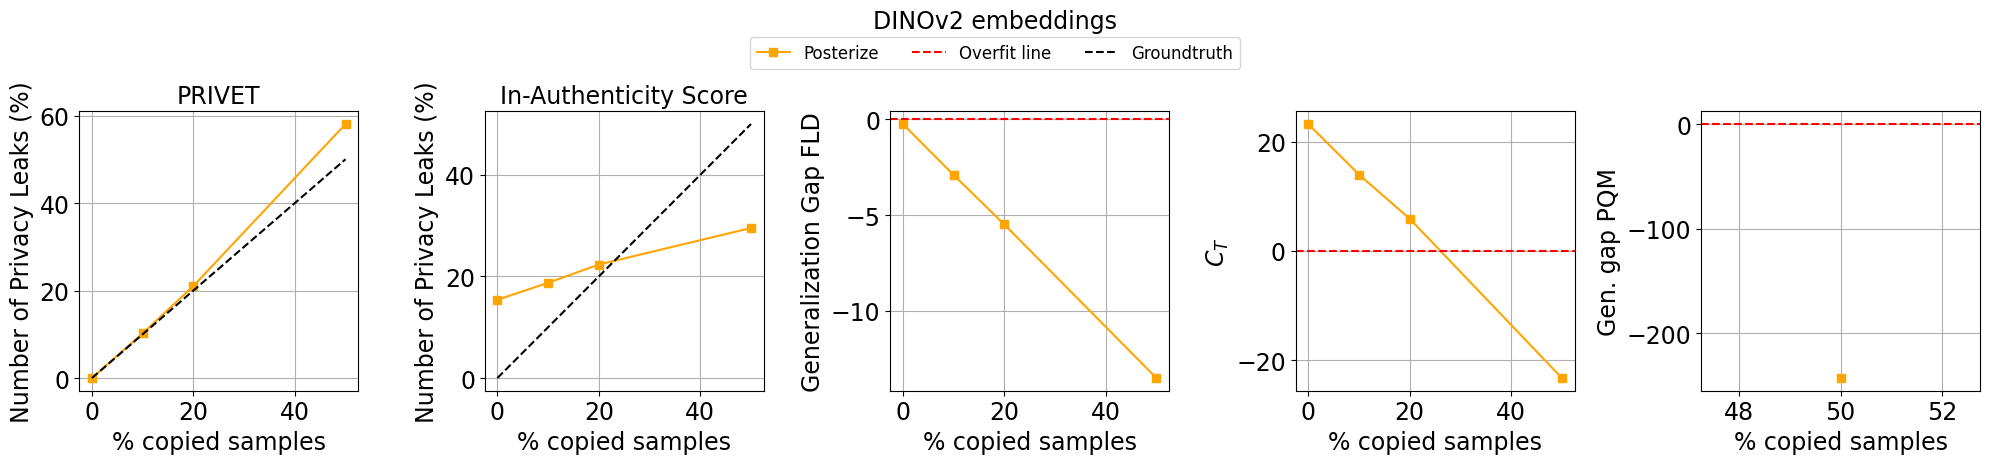

In [4]:
beta_values = [0,0.1,0.2,0.5] #[0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

FONTSIZE=17

plt.rcParams.update({
    'axes.labelsize': FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'xtick.labelsize': FONTSIZE,
    'ytick.labelsize': FONTSIZE
})

styles = {
    'Posterize': {'color':'orange', 'marker':'s'},
    'Center crop 28': {'color':'green',  'marker':'.'},
    'JPG 75':     {'color':'violet',   'marker':'D'},
    'Elastic transform':     {'color':'blue',   'marker':'x'}
}

# 'JPG 75':     {'color':'violet',   'marker':'D'},

transform_names = ['Posterize'] #, 'Center crop 28', 'JPG 75' ,'Elastic transform']

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20,4))

x = [b * 100 for b in beta_values]   # percent copied

# 1) NPL (PRIVET)
ax = axs[0]
for name in transform_names:
    ax.plot(x, 100*np.array(metrics[name]['NPL'])/10_000,
            label=name,
            color=styles[name]['color'],
            marker=styles[name]['marker'],
            linestyle='-')
ax.plot(x,x, color="black", linestyle="dashed",label="groundtruth")
ax.set_xlabel("% copied samples")
ax.set_ylabel("Number of Privacy Leaks (%)")
ax.set_title("PRIVET")
#ax.axhline(0, color='red', linestyle='--', label="Overfit line (below is overfit)")
#ax.legend(fontsize=12)
ax.grid(True)

# 2) Auth
ax = axs[1]
for name in transform_names:
    ax.plot(x, 100*np.array(metrics[name]['Auth'])/10_000,
            label=name,
            color=styles[name]['color'],
            marker=styles[name]['marker'],
            linestyle='-')
ax.plot(x,x, color="black", linestyle="dashed",label="groundtruth")
ax.set_xlabel("% copied samples")
ax.set_ylabel("Number of Privacy Leaks (%)")
ax.set_title("In-Authenticity Score")
#ax.axhline(0, color='red', linestyle='--', label="Overfit line (below is overfit)")
ax.grid(True)

# 2) Generalization Gap FLD
ax = axs[2]
for name in transform_names:
    ax.plot(x, metrics[name]['FLD'],
            label=name,
            color=styles[name]['color'],
            marker=styles[name]['marker'],
            linestyle='-')
ax.set_xlabel("% copied samples")
ax.set_ylabel("Generalization Gap FLD")
#ax.set_title("Generalization Gap FLD")
ax.axhline(0, color='red', linestyle='--', label="Overfit line")
ax.grid(True)


# 4) $C_T$
ax = axs[3]
for name in transform_names:
    ax.plot(x, metrics[name]['CT'],
            label=name,
            color=styles[name]['color'],
            marker=styles[name]['marker'],
            linestyle='-')
ax.set_xlabel("% copied samples")
ax.set_ylabel("$C_T$")
#ax.set_title("$C_T$")
ax.axhline(0, color='red', linestyle='--', label="Overfit line")
ax.grid(True)

# 4) $C_T$
ax = axs[4]
for name in transform_names:
    ax.plot(x, metrics[name]['PQM'],
            label=name,
            color=styles[name]['color'],
            marker=styles[name]['marker'],
            linestyle='-')
ax.set_xlabel("% copied samples")
ax.set_ylabel("Gen. gap PQM")
#ax.set_title("$C_T$")
ax.axhline(0, color='red', linestyle='--', label="Overfit line")
ax.grid(True)

tmp = axs[2].get_legend_handles_labels()
tmp[1].insert(3,"Groundtruth")
tmp[0].insert(3,axs[1].get_legend_handles_labels()[0][-1])


fig.legend(
    *tmp,
    loc='upper center',
    bbox_to_anchor=[0.5, 1.1],
    ncol=6,
    fontsize=12
)


fig.tight_layout()

plt.suptitle("DINOv2 embeddings",y=1.15,fontsize=FONTSIZE)


plt.show()

Repeat the same code for CIFAR10 copycat on wavelet features